In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from src_gypsum import utils
import flopy
import xmf6

In [2]:
# Usamos LaTeX para los tectos de la figura.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  
    "font.serif": ["Computer Modern Roman"],
})

In [3]:
def data_recovery(filename):
    #
    # --- Leemos el archivo con los resultados de TR_1D_oper.exe ---
    with open(filename, "r") as f:
            lines = f.readlines()
    #
    # Obtenemos la concentración de las dos especies
    key_string = "Final concentration of aqueous species:"
    i = xmf6.find_index(lines, key_string, 2)
    conc = [np.array(l.split(), dtype=float) for l in lines[i:i+2]]

    return conc

In [4]:
def data_recovery_excel(filename, tsel = 10):
    #
    # Concentraciones de los dos especies al tiempo 'tsel'
    c1 = pd.read_excel(filename, sheet_name='c_1').iloc[11:,tsel+5].to_numpy()     
    c2 = pd.read_excel(filename, sheet_name='c_2').iloc[11:,tsel+5].to_numpy()
    #
    # Solución analítica de los dos especies al tiempo 'tsel'
    an_tsel = 5 + tsel // 10 
    an_c1 = pd.read_excel(filename, sheet_name='An_C1').iloc[11:,an_tsel].to_numpy()
    an_c2 = pd.read_excel(filename, sheet_name='An_C2').iloc[11:,an_tsel].to_numpy()

    return c1, c2, an_c1, an_c2

In [5]:
# Cargamos el modelo de flujo
o_sim = flopy.mf6.MFSimulation.load(
    sim_ws="io_mf6/gwf_gwt_comp",
    verbosity_level=0)

# Obtenemos el objetos del modelo
o_gwt = o_sim.get_model("transport")

# Recuperamos las coordenadas del dominio
grid = o_gwt.modelgrid

# Recuperamos las coordenadas de los centros de las celdas de la malla
x = grid.xcellcenters[0] # centros de los volúmenes
print(x)

times = ["10d", "20d", "30d", "40d"]
print(times)

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
['10d', '20d', '30d', '40d']


In [6]:
nspec = 3
#
# Leer información de "u_init.dat"
with open("rt_workingDir/u_init_yeso.dat", "r") as f:
    spec_info = f.readlines()
key_string = "  Aqueous variable activity species:"
isp = utils.find_index(spec_info, key_string, 1)
spec_names = [l.split(": ")[1].strip() for l in spec_info[isp:isp+nspec]]
print(f"Especies: {spec_names}")

#
# Leer información de la simulación : componentes
with open("rt_workingDir/gypsum_final_species.dat", "r") as f:
    lines = f.readlines()
steps = len(lines) // nspec
print(f"Pasos de tiempo: {steps}")

tsel = 10
c1_com = np.array([float(l) for l in lines[0 + tsel * nspec].split()][1:])
c2_com = np.array([float(l) for l in lines[2 + tsel * nspec].split()][1:])

# Datos del excel (solución exacta)
c1, c2, an_c1, an_c2 = data_recovery_excel("nr_analysis/comparativa_02.xlsx", tsel = tsel)
# Generados con GWT
c_mf6 = data_recovery("../02_Rt_WMA_gypsum_1D/nr_analysis/gypsum_eq_exch.out")
# Generados con DFC
c_dfc = data_recovery("../02_Rt_WMA_gypsum_1D/nr_analysis/gypsum_eq_dfc.out")

numres = dict(
    c1_com = [c1_com],
    c2_com = [c2_com],
    c1_mf6 = [c_mf6[0]],
    c2_mf6 = [c_mf6[1]],
    c1_dfc = [c_dfc[0]],
    c2_dfc = [c_dfc[1]],
)

xmf6.nice_print("Numerical results: gypsum", numres)

Especies: ['ca+2', 'cl-', 'so4-2']
Pasos de tiempo: 41

Numerical results: gypsum
―――――――――――――――――――――――――
c1_com = ―― data array ――
       = [ 1.00004  1.00007  1.00022  1.00098  1.00469  1.02154  1.09195  1.35794
  2.24271  4.7334  10.3079  19.2441  28.5808  33.2866  32.3032  27.7782
 20.8263  13.9154   8.56263  5.05501  3.02067  1.9468   1.42102  1.17899
  1.07319  1.02894  1.01112  1.00417  1.00154  1.00054]
c2_com = ―― data array ――
       = [3.29370e-05 3.29360e-05 3.29311e-05 3.29059e-05 3.27843e-05 3.22436e-05
 3.01647e-05 2.42560e-05 1.46868e-05 6.95868e-06 3.19544e-06 1.71160e-06
 1.15246e-06 9.89534e-07 1.01966e-06 1.18576e-06 1.58156e-06 2.36704e-06
 3.84674e-06 6.51596e-06 1.09043e-05 1.69191e-05 2.31793e-05 2.79377e-05
 3.06918e-05 3.20118e-05 3.25761e-05 3.28015e-05 3.28876e-05 3.29204e-05]
c1_mf6 = ―― data array ――
       = [ 1.00003  1.00031  1.00145  1.00619  1.02487  1.09316  1.32068  1.99545
  3.72072  7.35246 13.2469  20.0574  25.4864  27.8767  26.9732  23.6318
 1

In [9]:
# GWT error
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1_mf6 = np.linalg.norm(an_c1 - c_mf6[0]) / np.sqrt(len(c_mf6[0]))
RMSE2_mf6 = np.linalg.norm(an_c2 - c_mf6[1]) / np.sqrt(len(c_mf6[1]))
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1_mf6 = np.mean(np.abs((an_c1 - c_mf6[0]) / an_c1)) * 100
MAPE2_mf6 = np.mean(np.abs((an_c2 - c_mf6[1]) / an_c2)) * 100

xmf6.nice_print("GWT Error")
print(f"RMSE c1: {RMSE1_mf6:5.2e} \t RMSE c2: {RMSE2_mf6:5.2e}")
print(f"MAPE c1: {MAPE1_mf6:5.2f}% \t MAPE c2: {MAPE2_mf6:5.2f}%")

# DFC error
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1_dfc = np.linalg.norm(an_c1 - c_dfc[0]) / np.sqrt(len(c_dfc[0]))
RMSE2_dfc = np.linalg.norm(an_c2 - c_dfc[1]) / np.sqrt(len(c_dfc[1]))
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1_dfc = np.mean(np.abs((an_c1 - c_dfc[0]) / an_c1)) * 100
MAPE2_dfc = np.mean(np.abs((an_c2 - c_dfc[1]) / an_c2)) * 100

xmf6.nice_print("DFC Error")
print(f"RMSE c1: {RMSE1_dfc:5.2e} \t RMSE c2: {RMSE2_dfc:5.2e}")
print(f"MAPE c1: {MAPE1_dfc:5.2f}% \t MAPE c2: {MAPE2_dfc:5.2f}%")

# Component error
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1_com = np.linalg.norm(an_c1 - c1_com) / np.sqrt(len(c_dfc[0]))
RMSE2_com = np.linalg.norm(an_c2 - c2_com) / np.sqrt(len(c_dfc[1]))
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1_com = np.mean(np.abs((an_c1 - c1_com) / an_c1)) * 100
MAPE2_com = np.mean(np.abs((an_c2 - c2_com) / an_c2)) * 100

xmf6.nice_print("Component Error")
print(f"RMSE c1: {RMSE1_com:5.2e} \t RMSE c2: {RMSE2_com:5.2e}")
print(f"MAPE c1: {MAPE1_com:5.2f}% \t MAPE c2: {MAPE2_com:5.2f}%")


GWT Error
―――――――――

RMSE c1: 1.48e+00 	 RMSE c2: 3.45e-06
MAPE c1: 14.97% 	 MAPE c2: 12.43%

DFC Error
―――――――――

RMSE c1: 1.48e+00 	 RMSE c2: 3.45e-06
MAPE c1: 14.97% 	 MAPE c2: 12.43%

Component Error
―――――――――――――――

RMSE c1: 1.97e+00 	 RMSE c2: 2.95e-06
MAPE c1: 12.46% 	 MAPE c2: 16.29%


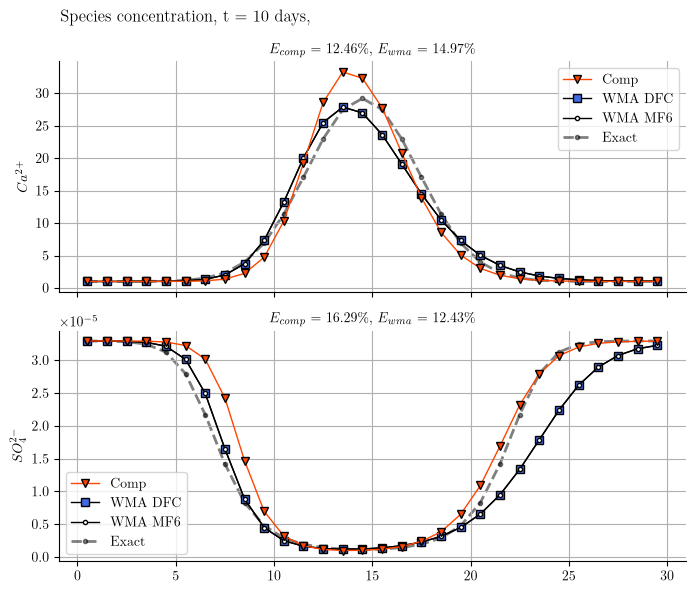

In [16]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7,6))

# Graficación a apartir del paso 1.
#for nt in range(1, 40, 1):
#    lw = 2 if nt == 1 else 0.5
#    ax[0].plot(x, [float(l) for l in lines[0 + nt * nspec].split()][1:], lw=lw, color='silver')
#    ax[1].plot(x, [float(l) for l in lines[2 + nt * nspec].split()][1:], lw=lw, color='silver')

alpha = 1.00
markersize = 6

ax[0].plot(x, [float(l) for l in lines[0 + tsel * nspec].split()][1:], 
           lw=1.0, ls = "-", marker='v', markersize=markersize, markeredgecolor="black", 
           color='orangered', alpha=alpha, zorder = 5, label=f"Comp")
ax[1].plot(x, [float(l) for l in lines[2 + tsel * nspec].split()][1:], 
           lw=1.0, ls = "-", marker='v', markersize=markersize, markeredgecolor="black", 
           color='orangered', alpha=alpha, zorder = 5, label=f"Comp")

# Solución con DFC
ax[0].plot(x, c_dfc[0], 's-', c = "black", mec="black", mfc="royalblue", lw = 1.0,
           alpha=alpha, zorder = 4, label = f"WMA DFC")
ax[1].plot(x, c_dfc[1], 's-', c = "black", mec="black", mfc="royalblue", lw = 1.0,
           alpha=alpha, zorder = 4, label = f"WMA DFC")

# Solución con MODFLOW
ax[0].plot(x, c_mf6[0], '.-', c = "black", mec="black", mfc="white", lw = 1.0,
           alpha=alpha, zorder = 4, label = f"WMA MF6")
ax[1].plot(x, c_mf6[1], '.-', c = "black", mec="black", mfc="white", lw = 1.0,
           alpha=alpha, zorder = 4, label = f"WMA MF6")

# Solución exacta
ax[0].plot(x, an_c1, ".--", lw = 2, color="black", label = f"Exact", alpha = 0.5, zorder = 1)
ax[1].plot(x, an_c2, ".--", lw = 2, color="black", label = f"Exact", alpha = 0.5, zorder = 1)

ax[0].set_ylabel("$Ca^{2+}$") 
ax[1].set_ylabel("$SO_4^{2-}$")
    
ax[0].grid()
ax[1].grid()

ax[0].legend()
ax[1].legend()

ax[0].spines.right.set_visible(False)
ax[0].spines.top.set_visible(False)
ax[1].spines.right.set_visible(False)
ax[1].spines.top.set_visible(False)

c1_title = "$E_{comp}$ = " + f"{MAPE1_com:5.2f}" + r"$\%$, "
c1_title += "$E_{wma}$ = " + f"{MAPE1_mf6:5.2f}" + r"$\%$"
c2_title = "$E_{comp}$ = " + f"{MAPE2_com:5.2f}" + r"$\%$, "
c2_title += "$E_{wma}$ = " + f"{MAPE2_mf6:5.2f}" + r"$\%$"

ax[0].set_title(c1_title, fontsize=10)
ax[1].set_title(c2_title, fontsize=10)

title = f"Species concentration, t = {tsel} days" 

plt.suptitle(title, x=0.085, ha="left")
plt.tight_layout()
plt.savefig("componentes_yeso.pdf")
plt.show()